<a href="https://colab.research.google.com/github/rafidfajar/data-science-2026/blob/main/Pertemuan10_Muhamad_Rafid_Fajar_250401020195.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Nama    :** Muhamad Rafid Fajar
### **NIM     :** 250401020195
### **Kelas   :** IF401

In [2]:
import pandas as pd


df = pd.read_csv("telco_churn.csv")

print(df.shape)
print(df["Churn"].value_counts(normalize=True))


if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df = df.dropna()


y = df["Churn"].map({"No": 0, "Yes": 1})


X = df.drop("Churn", axis=1)

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_tr, y_tr)

from sklearn.metrics import classification_report, roc_auc_score


y_pred = rf.predict(X_te)


y_prob = rf.predict_proba(X_te)[:, 1]


print("Classification Report")
print(classification_report(y_te, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_te, y_prob))


hasil = pd.DataFrame({
    "Actual": y_te.values[:10],
    "Prob_Churn": y_prob[:10]
})

print("\nProbabilitas Churn:")
print(hasil)

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8198746188610092

Probabilitas Churn:
   Actual  Prob_Churn
0       0    0.010000
1       0    0.700000
2       0    0.016667
3       1    0.045793
4       0    0.156667
5       1    0.226667
6       0    0.020000
7       0    0.200000
8       1    0.703333
9       0    0.000000


Accuracy Score: 0.7874911158493249

Confusion Matrix:
 [[925 108]
 [191 183]]


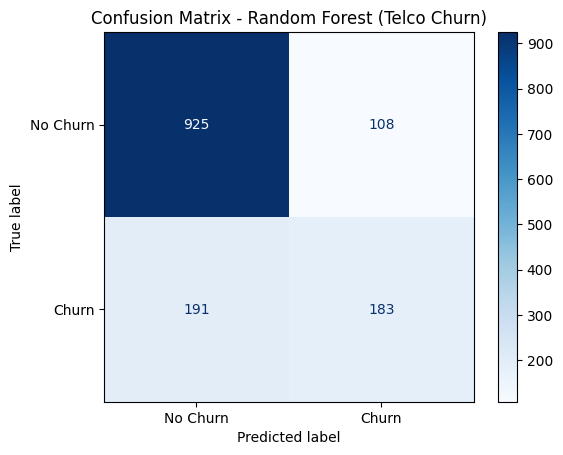

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

print("Accuracy Score:", accuracy_score(y_te, y_pred))

cm = confusion_matrix(y_te, y_pred)
print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Telco Churn)")
plt.show()

Kesimpulan :

Dari hasil pengujian, model Random Forest ini cukup baik dalam mengklasifikasikan pelanggan yang berpotensi churn, terlihat dari ROC-AUC sebesar 0,820. Tapi karena data churn ini imbalanced (73,5% No Churn vs 26,5% Churn), saya rasa Accuracy (0,787) saja belum cukup mewakili performa model, karena angka setinggi itu bisa saja dicapai hanya dengan menebak "No Churn" terus-menerus.

Menurut saya, metrik yang lebih penting untuk diperhatikan adalah Recall (0,49) dan F1-Score (0,55), sebab dalam kasus churn, kesalahan yang lebih berisiko adalah ketika pelanggan yang sebenarnya akan churn justru tidak terdeteksi (False Negative), karena artinya perusahaan kehilangan kesempatan melakukan retensi. Precision (0,63) tetap perlu dijaga agar strategi retensi tidak salah sasaran ke pelanggan yang sebenarnya tidak berisiko.

Selain itu, model ini juga menghasilkan probabilitas churn untuk tiap pelanggan, yang menurut saya bisa dimanfaatkan perusahaan untuk memprioritaskan pelanggan berisiko tinggi dalam strategi retensinya, sehingga pendekatannya lebih terarah dan berbasis data.